# **RIDGE regression**

Marek Šugár

After validating the near-optimal settings for the model in terms of **Training Window length** and the regularization parameter $\lambda$ or as in the <code>sklearn</code> we have $\alpha$, model was run on the all the stocks data included.

We have been able to localize near-optimal setting (*near* because of the excessive computation costs) as <code>TrainingWindow=4</code> and $\lambda$=100.

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import Ridge


In [3]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **RIDGE regression**

In [ ]:
performance_tracker = {}
performance_mean = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 4 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_mean[ticker] = []

    MAPEs = []
    AccuracyMean = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = Ridge(alpha=100)

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))
        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))    
        
    performance_tracker[ticker] = MAPEs.copy()

In [14]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

The overall average deaviation among all the rolling forecast runs among all the <code>65</code> stocks was $\approx 1.7673 \%$, which comparatively to the benchmarking <code>KNN / Random Walk</code> is worse performance however, only by few hundreths of a %.

In [16]:
np.mean(list(mean_performances.values()))

np.float64(1.7673914181642019)

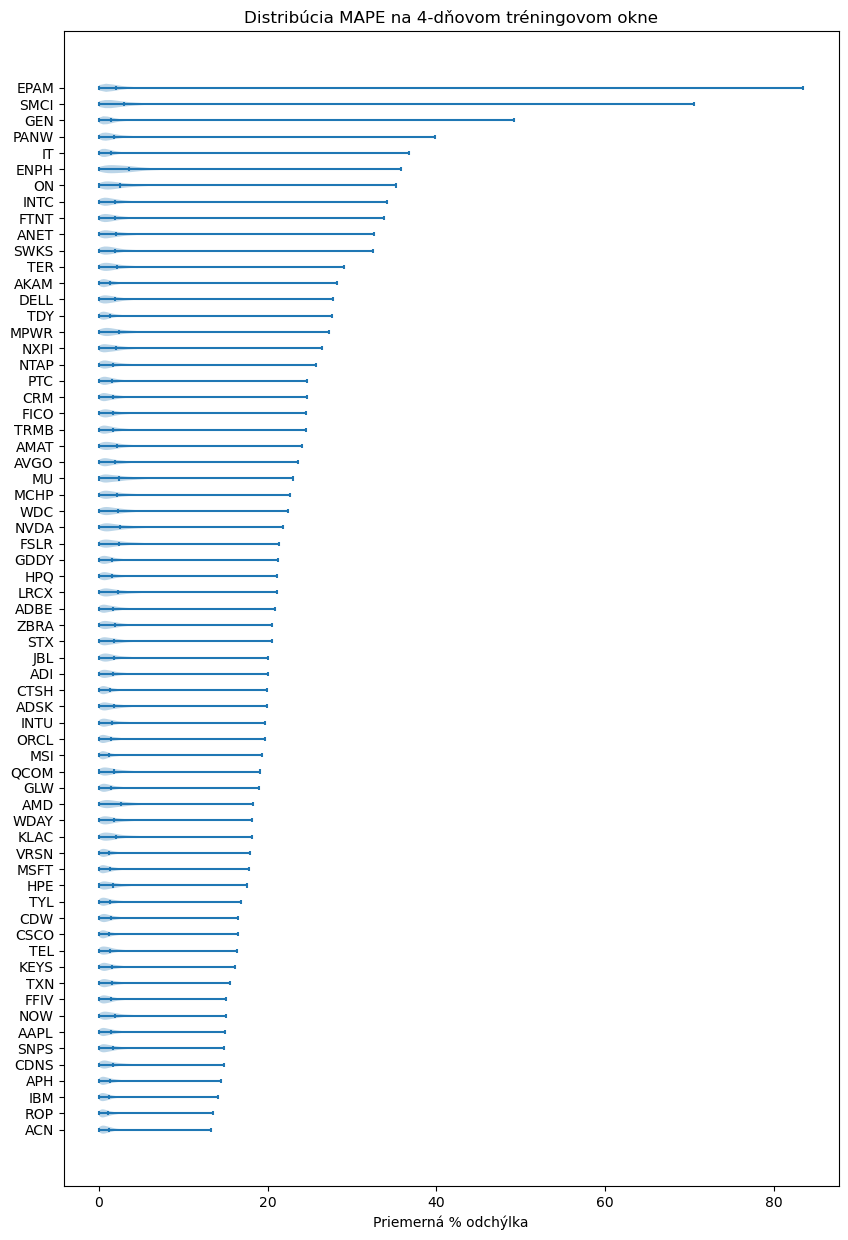

In [17]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

Here we include mean deviation results for single stocks' tickers.

In [18]:
mean_performances

{'ROP': np.float64(1.08961308921466),
 'IBM': np.float64(1.1483646545676403),
 'MSI': np.float64(1.180151578152992),
 'CSCO': np.float64(1.182543366831212),
 'VRSN': np.float64(1.2045831860850225),
 'ACN': np.float64(1.2378108506030732),
 'CTSH': np.float64(1.27378624805622),
 'APH': np.float64(1.2844468339352328),
 'TDY': np.float64(1.2889216673893455),
 'MSFT': np.float64(1.3294942458465655),
 'AKAM': np.float64(1.3493263438179008),
 'TYL': np.float64(1.363335926284727),
 'TEL': np.float64(1.3662565826558921),
 'ORCL': np.float64(1.3752502493493346),
 'FFIV': np.float64(1.3820600107181018),
 'IT': np.float64(1.3889876532937384),
 'CDW': np.float64(1.4156752380992124),
 'GLW': np.float64(1.4379649827267058),
 'AAPL': np.float64(1.4510475022032001),
 'GEN': np.float64(1.4687395057071475),
 'TXN': np.float64(1.513248622216715),
 'KEYS': np.float64(1.5147468658945713),
 'GDDY': np.float64(1.537490617759066),
 'PTC': np.float64(1.5620219683309644),
 'INTU': np.float64(1.5955629096802522),